# Machine Learning Model Deployment


- Um classificador de scores de vídeos do IMDB  com o MLflow no Databricks.
- **Dataset:**
Amostras do [IMDB (Internet Movie Database)](https://developer.imdb.com/non-commercial-datasets/)  

## Libs

In [0]:
import os
from pathlib import Path
import sys
from tqdm import tqdm

ROOT_DIR = Path.cwd().parent
sys.path.append(str(ROOT_DIR))

import matplotlib.pyplot as plt
import seaborn as sns

from pyspark.sql import SparkSession
import pyspark.sql.functions as F
from pyspark.ml.feature import VectorAssembler
from pyspark.sql.types import StringType
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator

import mlflow
import mlflow.spark
from mlflow.models import infer_signature
from graphics.graphs import plot_confusion_matrix

In [0]:
DATA_PATH = '/Volumes/studies/studies_imdb/sample_imdb/data'
TEMP_PATH = '/Volumes/studies/studies_imdb/sample_imdb/temp'

## Dataset

In [0]:
df = spark.read.csv(f'{DATA_PATH}/dataset_reduced_imdb.csv', header=True, inferSchema=True)

print(f'# Amostras: {df.count():_}')
df.limit(24).toPandas()

# Amostras: 1_650


,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt22489120,movie,La Lucha: Getting Schooled in America,La Lucha: Getting Schooled in America,0,2023,\N,80,Documentary,9.9,62
1,tt21987706,movie,Dancing with Mom,Dancing with Mom,0,2022,\N,76,Documentary,9.7,69
2,tt9032398,movie,The Fire Cats,The Fire Cats: Save Something Small,0,2022,\N,80,Documentary,9.7,79
3,tt10703554,movie,The Book of Harth,The Book of Harth,0,2022,\N,62,Documentary,9.6,58
4,tt21062574,movie,Battle of Amritsar,Battle of Amritsar,0,2022,\N,156,Documentary,9.6,60
5,tt10218112,movie,Courageous Warriors Beauty from the Ashes,Courageous Warriors Beauty from the Ashes,0,2021,\N,91,Documentary,9.5,51
6,tt21110404,movie,Breaking la Vida,Breaking la Vida,0,2022,\N,93,Documentary,9.5,60
7,tt19879476,movie,War Dogs and I,War Dogs and I,0,2022,\N,60,Documentary,9.5,89
8,tt32250502,movie,The Years We Have Been Nowhere,The Years We Have Been Nowhere,0,2023,\N,80,Documentary,9.5,87
9,tt27133532,movie,Ambatukam: The Rise and Fall of Dreamybull,Ambatukam: The Rise and Fall of Dreamybull,0,2023,\N,45,Documentary,9.5,75


## Missing values

In [0]:
string_cols = [
    field.name
    for field in df.schema.fields
    if isinstance(field.dataType, StringType)
]

df.select([
    F.count(
        F.when(F.col(c) == r'\N', F.lit(1))
    ).alias(c)
    for c in string_cols
]).toPandas()

,tconst,titleType,primaryTitle,originalTitle,endYear,runtimeMinutes,genres
0,0,0,0,0,1650,155,0


In [0]:
df.limit(24).toPandas()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes
0,tt22489120,movie,La Lucha: Getting Schooled in America,La Lucha: Getting Schooled in America,0,2023,\N,80,Documentary,9.9,62
1,tt21987706,movie,Dancing with Mom,Dancing with Mom,0,2022,\N,76,Documentary,9.7,69
2,tt9032398,movie,The Fire Cats,The Fire Cats: Save Something Small,0,2022,\N,80,Documentary,9.7,79
3,tt10703554,movie,The Book of Harth,The Book of Harth,0,2022,\N,62,Documentary,9.6,58
4,tt21062574,movie,Battle of Amritsar,Battle of Amritsar,0,2022,\N,156,Documentary,9.6,60
5,tt10218112,movie,Courageous Warriors Beauty from the Ashes,Courageous Warriors Beauty from the Ashes,0,2021,\N,91,Documentary,9.5,51
6,tt21110404,movie,Breaking la Vida,Breaking la Vida,0,2022,\N,93,Documentary,9.5,60
7,tt19879476,movie,War Dogs and I,War Dogs and I,0,2022,\N,60,Documentary,9.5,89
8,tt32250502,movie,The Years We Have Been Nowhere,The Years We Have Been Nowhere,0,2023,\N,80,Documentary,9.5,87
9,tt27133532,movie,Ambatukam: The Rise and Fall of Dreamybull,Ambatukam: The Rise and Fall of Dreamybull,0,2023,\N,45,Documentary,9.5,75


## Trata valores nulos de runtimeMinutes

In [0]:
df = df.withColumn(
    'runtimeMinutes',
    F.expr('try_cast(runtimeMinutes as double)')
)

runtime_mean = df.select(
    F.mean('runtimeMinutes')
).first()[0]

if runtime_mean is not None:
    df = df.withColumn(
        'runtimeMinutes',
        F.coalesce(
            F.col('runtimeMinutes'),
            F.lit(runtime_mean)
        )
    )

df.select('runtimeMinutes').limit(10).toPandas()

,runtimeMinutes
0,80.0
1,76.0
2,80.0
3,62.0
4,156.0
5,91.0
6,93.0
7,60.0
8,80.0
9,45.0


## Define target

In [0]:
df = df.withColumn(
    'target',
    F.when(F.col('averageRating') > 7.5, 1).otherwise(0)
)

In [0]:
df.limit(5).toPandas()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,target
0,tt22489120,movie,La Lucha: Getting Schooled in America,La Lucha: Getting Schooled in America,0,2023,\N,80.0,Documentary,9.9,62,1
1,tt21987706,movie,Dancing with Mom,Dancing with Mom,0,2022,\N,76.0,Documentary,9.7,69,1
2,tt9032398,movie,The Fire Cats,The Fire Cats: Save Something Small,0,2022,\N,80.0,Documentary,9.7,79,1
3,tt10703554,movie,The Book of Harth,The Book of Harth,0,2022,\N,62.0,Documentary,9.6,58,1
4,tt21062574,movie,Battle of Amritsar,Battle of Amritsar,0,2022,\N,156.0,Documentary,9.6,60,1


In [0]:
df.orderBy(F.monotonically_increasing_id().desc()).limit(5).toPandas()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,target
0,tt23016770,movie,Chic & Classic: Meghan Markle,Chic & Classic: Meghan Markle,0,2022,\N,52.000000,Documentary,1.3,57,0
1,tt32636077,movie,Above and Below the Ground,Above and Below the Ground,0,2023,\N,86.000000,Documentary,1.4,78,0
2,tt14909626,movie,Don't Mess Up Our Race,Don't Mess Up Our Race,0,2021,\N,92.278261,Drama,1.4,71,0
3,tt27478726,movie,Red Flower,Gol-e Sorkh,0,2023,\N,76.000000,Comedy,2.1,61,0
4,tt16538780,movie,Aska Dair,Aska Dair,0,2022,\N,122.000000,Comedy,2.1,58,0


In [0]:
print('\nDistribuição do Target:')
df.groupBy('target').count().orderBy('target').toPandas()


Distribuição do Target:


,target,count
0,0,1276
1,1,374


## VectorAssembler das features

In [0]:
features_cols = ['numVotes', 'isAdult', 'startYear', 'runtimeMinutes']

assembler = VectorAssembler(
    inputCols=features_cols,
    outputCol='features'
)

ml_df = (
    assembler
    .transform(df)
)

ml_df.limit(10).toPandas()

,tconst,titleType,primaryTitle,originalTitle,isAdult,startYear,endYear,runtimeMinutes,genres,averageRating,numVotes,target,features
0,tt22489120,movie,La Lucha: Getting Schooled in America,La Lucha: Getting Schooled in America,0,2023,\N,80.0,Documentary,9.9,62,1,"[62.0, 0.0, 2023.0, 80.0]"
1,tt21987706,movie,Dancing with Mom,Dancing with Mom,0,2022,\N,76.0,Documentary,9.7,69,1,"[69.0, 0.0, 2022.0, 76.0]"
2,tt9032398,movie,The Fire Cats,The Fire Cats: Save Something Small,0,2022,\N,80.0,Documentary,9.7,79,1,"[79.0, 0.0, 2022.0, 80.0]"
3,tt10703554,movie,The Book of Harth,The Book of Harth,0,2022,\N,62.0,Documentary,9.6,58,1,"[58.0, 0.0, 2022.0, 62.0]"
4,tt21062574,movie,Battle of Amritsar,Battle of Amritsar,0,2022,\N,156.0,Documentary,9.6,60,1,"[60.0, 0.0, 2022.0, 156.0]"
5,tt10218112,movie,Courageous Warriors Beauty from the Ashes,Courageous Warriors Beauty from the Ashes,0,2021,\N,91.0,Documentary,9.5,51,1,"[51.0, 0.0, 2021.0, 91.0]"
6,tt21110404,movie,Breaking la Vida,Breaking la Vida,0,2022,\N,93.0,Documentary,9.5,60,1,"[60.0, 0.0, 2022.0, 93.0]"
7,tt19879476,movie,War Dogs and I,War Dogs and I,0,2022,\N,60.0,Documentary,9.5,89,1,"[89.0, 0.0, 2022.0, 60.0]"
8,tt32250502,movie,The Years We Have Been Nowhere,The Years We Have Been Nowhere,0,2023,\N,80.0,Documentary,9.5,87,1,"[87.0, 0.0, 2023.0, 80.0]"
9,tt27133532,movie,Ambatukam: The Rise and Fall of Dreamybull,Ambatukam: The Rise and Fall of Dreamybull,0,2023,\N,45.0,Documentary,9.5,75,1,"[75.0, 0.0, 2023.0, 45.0]"


## Split dataset into training and test

In [0]:
train_df, test_df = ml_df.randomSplit([0.8, 0.2], seed=42)

print(f'#Linhas treino: {train_df.count()}')
print(f'#Linhas de teste: {test_df.count()}')

#Linhas treino: 1363
#Linhas de teste: 287


### Export training and test datasets

In [0]:
train_df.toPandas().to_csv(f'{DATA_PATH}/train_df.csv', index=False)
test_df.toPandas().to_csv(f'{DATA_PATH}/test_df.csv', index=False)

In [0]:
test_df.groupBy('target').count().orderBy('target').toPandas()

,target,count
0,0,221
1,1,66


## MLFlow

In [0]:
mlflow.set_registry_uri('databricks-uc')

### Setup MLflow

In [0]:
print(mlflow.get_tracking_uri())

databricks


In [0]:
client = mlflow.MlflowClient()

def get_latest_version(model_name):
  model_version_infos = client.search_model_versions(f"name = '{model_name}'")
  return max([
    model_version_info.version for model_version_info in model_version_infos
  ])

In [0]:
model_name = f'studies.studies_imdb.rf_model'

mlflow.autolog(
  disable=False,
  silent=False,
  log_input_examples=False,
  log_model_signatures=True,
  log_models=True,
  log_traces=True
)

### Model registry

MLFlow ...
  > model_name: studies.studies_imdb.rf_model
  > Run ID: ecb28d3cdf804cb68f77879cd05483f2

  > Training ...
  > Model trained.

  > Metrics
  > ROC-AUC: 0.6087
  > PR-AUC:  0.3523


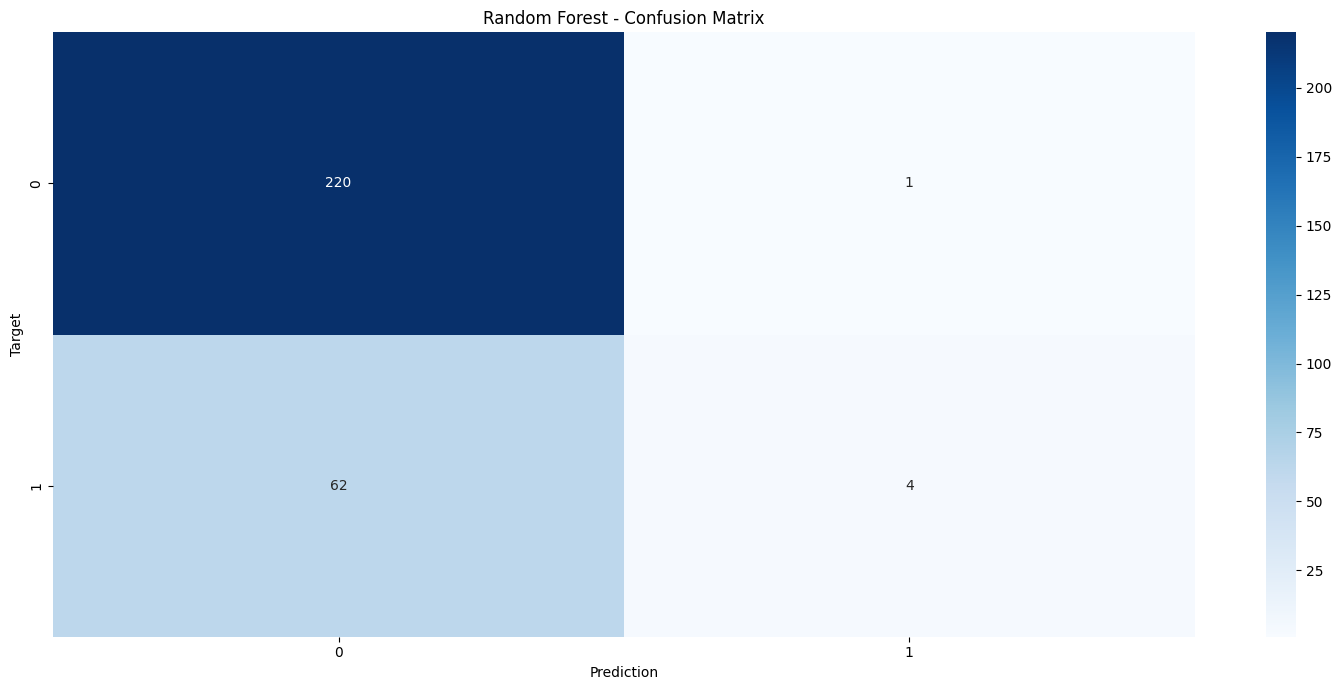

/databricks/python/lib/python3.12/site-packages/mlflow/types/utils.py:452: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/08/30 23:06:53 WARNING mlflow.utils.requirements_utils: Found pyspark version (4.1.0+databricks.connect.18.0.9) contains a local version label (+databricks.connect.18.0.9). MLflow logged a pip requirement for this package as 'pyspark==

Uploading artifacts:   0%|          | 0/24 [00:00<?, ?it/s]

🔗 Created version '1' of model 'workspace.default.rf_model': https://dbc-34ac7b3c-7a54.cloud.databricks.com/explore/data/models/workspace/default/rf_model/version/1?o=7474656785376246


MLflow run finished.


In [0]:
n_trees = 200
max_depth = 6

print('MLFlow ...')
print(f'  > model_name: {model_name}')

with mlflow.start_run(run_name='random_forest_v0') as mlflow_run:
    print(f'  > Run ID: {mlflow_run.info.run_id}')
    mlflow.log_params({
        'model': 'RandomForest',
        'numTrees': n_trees,
        'maxDepth': max_depth,
        'seed': 42
    })

    print('\n  > Training ...')
    model_rf = RandomForestClassifier(
        featuresCol='features',
        labelCol='target',
        numTrees=n_trees,
        maxDepth=max_depth,
        seed=42
    )
    model = model_rf.fit(train_df)
    print('  > Model trained.')

    preds = model.transform(test_df)
    # preds = model.transform(train_df)

    print('\n  > Metrics')
    # Evaluation
    evaluator_roc = BinaryClassificationEvaluator(
        labelCol='target',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderROC'
    )
    evaluator_pr = BinaryClassificationEvaluator(
        labelCol='target',
        rawPredictionCol='rawPrediction',
        metricName='areaUnderPR'
    )
    roc_auc = evaluator_roc.evaluate(preds)
    pr_auc = evaluator_pr.evaluate(preds)
    print(f'  > ROC-AUC: {roc_auc:.4f}')
    print(f'  > PR-AUC:  {pr_auc:.4f}')
    mlflow.log_metrics({
        'roc_auc': roc_auc,
        'pr_auc': pr_auc
    })

    confusion_df = (
        preds
        .groupBy('target', 'prediction')
        .count()
        .orderBy('target', 'prediction')
    )
    confusion_rows = confusion_df.collect()

    cm = [[0, 0], [0, 0]]
    for row in confusion_rows:
        target = int(row['target'])
        prediction = int(row['prediction'])
        count = int(row['count'])
        cm[target][prediction] = count

    
    # Plot CM
    plt.figure(figsize=(15, 7))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=['0', '1'],
        yticklabels=['0', '1']
    )

    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('Random Forest - Confusion Matrix')
    plt.tight_layout()

    cm_path = f'{TEMP_PATH}/random_forest_confusion_matrix.png'
    plt.savefig(
        cm_path,
        dpi=150,
        bbox_inches='tight'
    )
    plt.show()


    mlflow.log_artifact(
        cm_path,
        artifact_path='evaluation'
    )

    signature = infer_signature(
        train_df.select(features_cols).limit(5),
        train_df.select('target').limit(5)
    )

    mlflow.spark.log_model(
        model,
        artifact_path='random_forest_artifacts',
        signature=signature,
        registered_model_name=model_name.split('.')[-1],
        dfs_tmpdir=TEMP_PATH
    )

    # Alias
    latest_version = get_latest_version(model_name)

    client.set_registered_model_alias(
        model_name,
        'RandomForest',
        latest_version
    )

print('MLflow run finished.')

<img src="imgs/model_artifacts_db.png">